In [1]:
# Zalecenie nr 2 z 20260820.txt (pkt 10): sprawdzic, czy klaster 2006-2009
# (wspolne ekstrema t0 w skanie 22 stacji, patrz 20260820b.ipynb) wynika z
# cechy KATALOGU TRZESIEN ZIEMI (np. lokalny klaster duzych zdarzen w tym
# okresie) czy WYLACZNIE ze strony CR (np. realna cecha strumienia
# promieniowania kosmicznego w rekordowym minimum slonecznym).
#
# Pomysl testu: t0 oznacza POCZATEK calego, ~9.2-letniego okna (P_days=3350)
# uzywanego w tescie znaku. Skoro ekstrema skanu grupuja sie w oknie
# 2006-2009 dla t0, to znaczy ze CALE oknO (np. 2006-2015 albo 2009-2018)
# ma nietypowo silna zgodnosc znakow miedzy Sm (suma magnitud) a |dCR|
# (zmiana CR). Sprawdzamy NIEZALEZNIE po obu stronach: czy suma magnitud
# ma nietypowy POZIOM/TREND w oknach zaczynajacych sie w tym okresie (efekt
# strony EQ, NIEZALEZNY od jakiejkolwiek CR), oraz analogicznie czy
# zmiennosc |dCR| ma nietypowy poziom w tych samych oknach (efekt strony
# CR). To PROSTY, SZYBKI test poziomu/trendu (rolling mean), nie odtwarza
# doslownie matematyki testu znaku (ktora zalezy od zgodnosci ZNAKOW
# wzgledem WEWNATRZOKIENNEJ mediany, nie tylko poziomu) - ale jest to
# tani (wektoryzowany, sekundy, ZERO ponownego liczenia pelnego skanu)
# pierwszy krok diagnostyczny, dokladnie taki, o jaki prosil Maciek.
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"
RESULTS_DIR = "../results"
P_DAYS = 3350

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}")

# Kilka reprezentatywnych stacji: dwie referencyjne (mosc, oulu) + najsilniejszy
# trafiony wynik z 20260820a (athn, sigma=6.90 przy d=5) + drugi najsilniejszy
# (hrms) + jedna slaba/kontrolna (sopb, nigdy nie bije progu).
REP_STATIONS = ["mosc", "oulu", "athn", "hrms", "sopb"]

def load_cr(station):
    if station == "mosc":
        df = pd.read_csv("../data/mosc_data.csv")
        df["datetime"] = pd.to_datetime(df["datetime"])
        return df.set_index("datetime").sort_index()["value"]
    if station == "oulu":
        df = pd.read_csv("../data/oulu_5min_data.csv")
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime"])
        return df.set_index("datetime").sort_index()["value"].resample("6h").mean()
    df = pd.read_csv(f"../data/csv_data_stations_full6h/{station}_full_6h.csv")
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]

cr_series = {s: load_cr(s) for s in REP_STATIONS}
for s, ser in cr_series.items():
    print(f"{s}: {len(ser)} pomiarow, {ser.index.min()} .. {ser.index.max()}")

# Ekstrema (t0) z juz zapisanego skanu (results/t0_scan_{stacja}_d5.csv) -
# do naniesienia na wykresy jako punkty odniesienia.
extrema_d5 = {}
for s in REP_STATIONS:
    df_scan = pd.read_csv(f"{RESULTS_DIR}/t0_scan_{s}_d5.csv", usecols=["t0", "PPDF"], parse_dates=["t0"])
    extrema_d5[s] = df_scan.loc[df_scan["PPDF"].idxmin(), "t0"]
print("Ekstrema (d=5):", {s: str(t) for s, t in extrema_d5.items()})


EQ (M>=4.0): 290945 zdarzen, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000
mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
oulu: 81816 pomiarow, 1970-01-01 00:00:00 .. 2025-12-31 18:00:00
athn: 29000 pomiarow, 2005-01-10 00:00:00 .. 2025-12-31 18:00:00
hrms: 20779 pomiarow, 2005-01-01 00:00:00 .. 2021-12-01 06:00:00
sopb: 23152 pomiarow, 2005-01-01 00:00:00 .. 2025-12-31 18:00:00
Ekstrema (d=5): {'mosc': '2008-02-26 00:00:00', 'oulu': '2006-01-26 12:00:00', 'athn': '2009-01-04 18:00:00', 'hrms': '2008-01-05 18:00:00', 'sopb': '2013-07-22 00:00:00'}


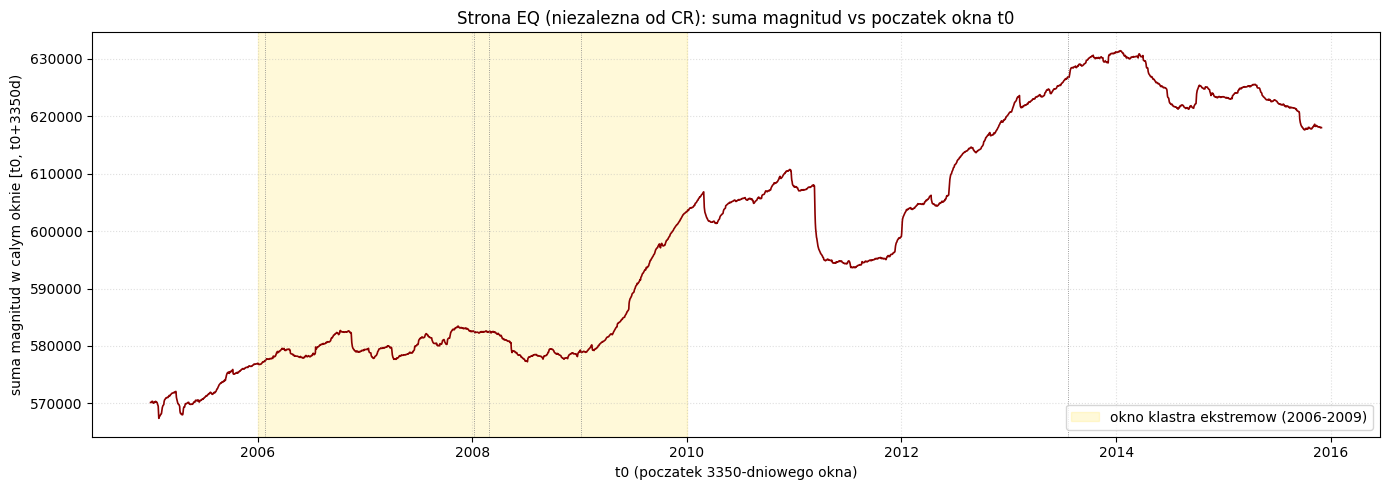

In [2]:
# KROK 1: strona EQ, calkowicie NIEZALEZNIE od jakiejkolwiek CR. Dla kazdego
# mozliwego t0 (poczatku okna) liczymy sume magnitud w calym, ~9.2-letnim
# oknie [t0, t0+P_days) - to jest DOKLADNIE ten sam "ladunek" (suma Sm), z
# ktorego test znaku buduje A_i, tylko zagregowany na caly przedzial zamiast
# po pojedynczych binach. Jesli okna zaczynajace sie w 2006-2009 maja
# WYRAZNIE inna (wyzsza/nizsza) sume magnitud niz okna zaczynajace sie
# gdzie indziej, to jest to cecha SAMEGO katalogu trzesien, niezalezna od
# jakiegokolwiek wyboru stacji CR.
eq_daily = eq.resample("1D").sum()
full_day_range = pd.date_range(eq.index.min().floor("D"), eq.index.max().floor("D"), freq="1D")
eq_daily = eq_daily.reindex(full_day_range, fill_value=0.0)

rolling_eq_sum = eq_daily.rolling(window=P_DAYS, min_periods=P_DAYS).sum()
# rolling_eq_sum.index[i] to KONIEC okna; przesuwamy indeks, zeby oznaczal
# POCZATEK okna (t0), zgodnie z konwencja skanu.
rolling_eq_by_t0 = rolling_eq_sum.copy()
rolling_eq_by_t0.index = rolling_eq_by_t0.index - pd.Timedelta(days=P_DAYS - 1)
rolling_eq_by_t0 = rolling_eq_by_t0.dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_eq_by_t0.index, rolling_eq_by_t0.values, color="darkred", lw=1.2)
ax.axvspan(pd.Timestamp("2006-01-01"), pd.Timestamp("2009-12-31"), color="gold", alpha=0.15,
           label="okno klastra ekstremow (2006-2009)")
for s, t0 in extrema_d5.items():
    ax.axvline(t0, color="gray", lw=0.6, ls=":")
ax.set_xlabel("t0 (poczatek 3350-dniowego okna)")
ax.set_ylabel("suma magnitud w calym oknie [t0, t0+3350d)")
ax.set_title("Strona EQ (niezalezna od CR): suma magnitud vs poczatek okna t0")
ax.legend()
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/eq_side_rolling_magnitude_sum.png", dpi=120)
plt.show()


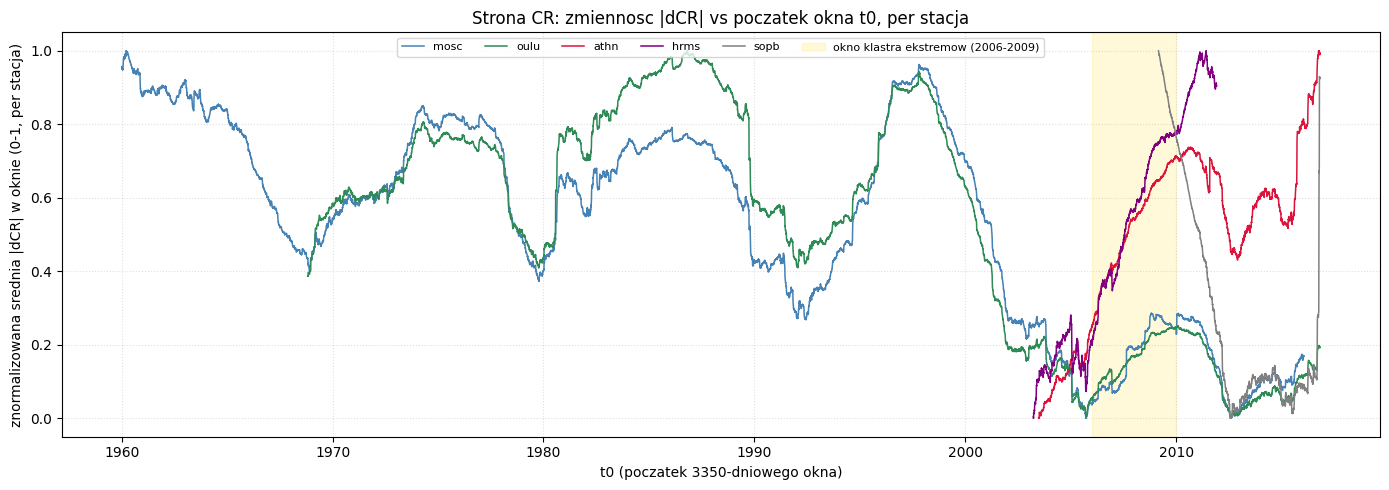

In [3]:
# KROK 2: strona CR, analogicznie - dla kazdej reprezentatywnej stacji
# liczymy dzienna |zmiane| CR, a potem rolling srednia tej zmiennosci w tym
# samym 3350-dniowym oknie. Wysoka wartosc = okres duzej "zmiennosci" CR
# (co dokladnie odpowiada B_i w tescie znaku, tylko zagregowane na cale
# okno zamiast po pojedynczych binach).
fig, ax = plt.subplots(figsize=(14, 5))
colors = {"mosc": "steelblue", "oulu": "seagreen", "athn": "crimson", "hrms": "purple", "sopb": "gray"}
rolling_cr_by_station = {}
for s in REP_STATIONS:
    cr_daily = cr_series[s].resample("1D").mean()
    dcr_daily_abs = cr_daily.diff().abs()
    rolling_vol = dcr_daily_abs.rolling(window=P_DAYS, min_periods=int(P_DAYS * 0.8)).mean()
    rolling_vol.index = rolling_vol.index - pd.Timedelta(days=P_DAYS - 1)
    rolling_vol = rolling_vol.dropna()
    rolling_cr_by_station[s] = rolling_vol
    # normalizacja do [0,1] TYLKO dla czytelnosci na wspolnym wykresie (rozne
    # stacje maja rozne jednostki/skale CR) - nie wplywa na ksztalt krzywej.
    norm = (rolling_vol - rolling_vol.min()) / (rolling_vol.max() - rolling_vol.min())
    ax.plot(norm.index, norm.values, color=colors.get(s, "black"), lw=1.1, label=s)

ax.axvspan(pd.Timestamp("2006-01-01"), pd.Timestamp("2009-12-31"), color="gold", alpha=0.15,
           label="okno klastra ekstremow (2006-2009)")
ax.set_xlabel("t0 (poczatek 3350-dniowego okna)")
ax.set_ylabel("znormalizowana srednia |dCR| w oknie (0-1, per stacja)")
ax.set_title("Strona CR: zmiennosc |dCR| vs poczatek okna t0, per stacja")
ax.legend(ncol=6, fontsize=8, loc="upper center")
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cr_side_rolling_volatility.png", dpi=120)
plt.show()


In [4]:
# KROK 3: ilosciowo - korelacja miedzy sila efektu w RZECZYWISTYM skanie
# (-log10 PPDF, z juz zapisanych wynikow) a (a) samym poziomem sumy
# magnitud w oknie (strona EQ, ta sama dla wszystkich stacji) i (b) sama
# zmiennoscia |dCR| w oknie (strona CR, rozna per stacja). Jesli korelacja
# z (a) jest silna i PODOBNA dla kazdej stacji (w tym dla sopb, ktora
# nigdy nie bije progu) - to argument, ze klaster wynika glownie z katalogu
# EQ. Jesli korelacja z (b) jest silna i ROSNIE dla stacji z mocniejszym
# wynikiem (athn, hrms) a slaba dla sopb - to argument za strona CR.
correlations = []
for s in REP_STATIONS:
    df_scan = pd.read_csv(f"{RESULTS_DIR}/t0_scan_{s}_d5.csv", usecols=["t0", "PPDF"], parse_dates=["t0"])
    df_scan["date"] = df_scan["t0"].dt.floor("D")
    scan_daily = df_scan.groupby("date")["PPDF"].mean()
    with np.errstate(divide="ignore"):
        strength_daily = -np.log10(np.clip(scan_daily, 1e-300, None))

    joined = pd.DataFrame({"strength": strength_daily}).join(
        pd.DataFrame({"eq_sum": rolling_eq_by_t0, "cr_vol": rolling_cr_by_station[s]}), how="inner"
    ).dropna()
    correlations.append(dict(
        station=s, n_points=len(joined),
        corr_strength_vs_eq_sum=joined["strength"].corr(joined["eq_sum"]),
        corr_strength_vs_cr_volatility=joined["strength"].corr(joined["cr_vol"]),
    ))

corr_df = pd.DataFrame(correlations)
print(corr_df.to_string(index=False))


station  n_points  corr_strength_vs_eq_sum  corr_strength_vs_cr_volatility
   mosc      3986                -0.615151                        0.121644
   oulu      3986                -0.717154                        0.280308
   athn      3986                -0.622166                       -0.108685
   hrms      2528                -0.411685                       -0.045988
   sopb      2465                 0.277012                       -0.134394


In [5]:
# KROK 4: wyniki KROK 1-3 sa NIEJEDNOZNACZNE (patrz interpretacja w
# rozmowie/dzienniku) - korelacje z KROK 3 sa niespojne co do znaku miedzy
# stacjami, a polozenie szczytu zmiennosci CR (w zakresie kandydatow t0)
# nie pokrywa sie scisle z ekstremum skanu dla zadnej stacji. Powod:
# rolling srednia/suma to przyblizenie POZIOMU, a prawdziwy test znaku
# zalezy od zgodnosci ZNAKOW wzgledem WEWNATRZOKIENNEJ mediany - to co
# innego (i wrazliwe na szczegoly, ktorych rolling mean nie widzi).
#
# Ostrzejszy, wciaz tani test: bezposrednio uzywajac PRAWDZIWEJ matematyki
# testu znaku (cosmoseismic_stat), ale TYLKO przy JEDNYM, juz znalezionym
# ekstremalnym t0 (nie caly skan) - wiec kazde wywolanie jest szybkie
# (pojedynczy test, nie 15943 kandydatow). Dwa niezalezne testy null:
#   (a) tasowanie magnitud EQ (czasy zdarzen bez zmian, tylko losowe
#       przemieszanie WARTOSCI magnitud miedzy nimi) - niszczy realna
#       strukturE czasowa "ktore konkretnie duze trzesienie bylo kiedy",
#       zachowujac liczbe zdarzen per bin i rozklad magnitud.
#   (b) cykliczne przesuniecie CR (ten sam wzorzec co dotychczasowe MC w
#       tym repo, mc_parallel.run_mc_parallel) - zachowuje CALA realna
#       autokorelacje/zmiennosc CR, tylko losowo przesuwa jej POLOZENIE w
#       czasie wzgledem EQ.
#
# Null-rozklady ORAZ podsumowanie zapisywane do results/ (jak inne wyniki
# symulacji w tym repo, np. mc_minima_*.npy) - zeby wykresy/tabela w
# kolejnych komorkach dalo sie odtworzyc bez ponownego liczenia (~1200
# wywolan cosmoseismic_stat).
from scipy.stats import binom, norm

def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)
    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def clip_to_eq_range(series):
    return series[(series.index >= eq.index.min()) & (series.index <= eq.index.max())]

TEST_STATIONS = ["athn", "hrms", "sopb"]  # najsilniejszy, drugi najsilniejszy, kontrola
N_SIMS = 200
rng = np.random.default_rng(42)

shuffle_results = []
null_distributions = {}  # station -> dict(eq_shuffle=array, cr_shift=array)
for s in TEST_STATIONS:
    t0 = extrema_d5[s]
    cr_clip = clip_to_eq_range(cr_series[s])
    real = cosmoseismic_stat(cr_clip, eq, t0, P_DAYS, 5, 4.0, 0)

    # (a) tasowanie magnitud EQ, czasy bez zmian
    eq_shuffle_ppdf = []
    eq_vals = eq.to_numpy().copy()
    for _ in range(N_SIMS):
        shuffled_vals = rng.permutation(eq_vals)
        eq_shuffled = pd.Series(shuffled_vals, index=eq.index)
        r = cosmoseismic_stat(cr_clip, eq_shuffled, t0, P_DAYS, 5, 4.0, 0)
        eq_shuffle_ppdf.append(r["PPDF"])
    eq_shuffle_ppdf = np.array(eq_shuffle_ppdf)
    p_eq_shuffle = np.mean(eq_shuffle_ppdf <= real["PPDF"])

    # (b) cykliczne przesuniecie CR (losowy offset, zawijanie)
    cr_shift_ppdf = []
    cr_vals_arr = cr_clip.to_numpy()
    n_cr = len(cr_vals_arr)
    for _ in range(N_SIMS):
        offset = rng.integers(1, n_cr - 1)
        cr_shifted_vals = np.roll(cr_vals_arr, offset)
        cr_shifted = pd.Series(cr_shifted_vals, index=cr_clip.index)
        r = cosmoseismic_stat(cr_shifted, eq, t0, P_DAYS, 5, 4.0, 0)
        cr_shift_ppdf.append(r["PPDF"])
    cr_shift_ppdf = np.array(cr_shift_ppdf)
    p_cr_shift = np.mean(cr_shift_ppdf <= real["PPDF"])

    null_distributions[s] = dict(eq_shuffle=eq_shuffle_ppdf, cr_shift=cr_shift_ppdf, real_ppdf=real["PPDF"], t0=t0)
    np.save(f"{RESULTS_DIR}/eq_shuffle_null_ppdf_{s}.npy", eq_shuffle_ppdf)
    np.save(f"{RESULTS_DIR}/cr_shift_null_ppdf_{s}.npy", cr_shift_ppdf)

    shuffle_results.append(dict(
        station=s, t0=str(t0.date()), real_PPDF=real["PPDF"], real_sigma=real["sigma"],
        frac_eq_shuffle_as_extreme=p_eq_shuffle, frac_cr_shift_as_extreme=p_cr_shift,
    ))

shuffle_df = pd.DataFrame(shuffle_results)
shuffle_df.to_csv(f"{RESULTS_DIR}/eq_cr_shuffle_test_summary.csv", index=False)
print(shuffle_df.to_string(index=False))
print("\nInterpretacja: 'frac_eq_shuffle_as_extreme' bliskie 1 = tasowanie EQ NIE niszczy wyniku")
print("(realna kolejnosc magnitud nie ma znaczenia - wynik to wlasciwosc Sm per bin, nie konkretnej sekwencji).")
print("'frac_cr_shift_as_extreme' bliskie 1 = przesuniecie CR NIE niszczy wyniku")
print("(realne wyrownanie w czasie nie ma znaczenia). Wartosci bliskie 0 = dany czynnik JEST istotny.")


station         t0    real_PPDF  real_sigma  frac_eq_shuffle_as_extreme  frac_cr_shift_as_extreme
   athn 2009-01-04 1.141569e-12    6.896936                       0.765                     0.000
   hrms 2008-01-05 1.992878e-11    6.470581                       0.795                     0.000
   sopb 2013-07-22 2.247344e-04    3.100956                       0.720                     0.035

Interpretacja: 'frac_eq_shuffle_as_extreme' bliskie 1 = tasowanie EQ NIE niszczy wyniku
(realna kolejnosc magnitud nie ma znaczenia - wynik to wlasciwosc Sm per bin, nie konkretnej sekwencji).
'frac_cr_shift_as_extreme' bliskie 1 = przesuniecie CR NIE niszczy wyniku
(realne wyrownanie w czasie nie ma znaczenia). Wartosci bliskie 0 = dany czynnik JEST istotny.


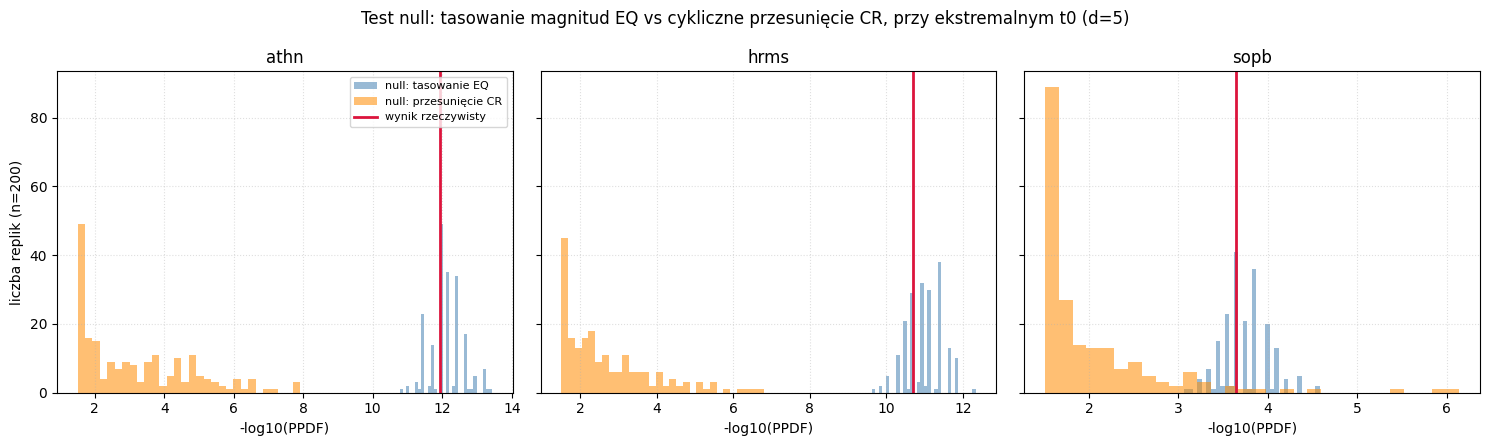

In [6]:
# KROK 5: wykres do wklejenia w dzienniku - rozklady null (tasowanie EQ vs
# przesuniecie CR) na tle prawdziwego wyniku, per stacja. Wczytane z
# zapisanych plikow (results/*_null_ppdf_{stacja}.npy) - niezalezne od
# pamieci kernela, wiec da sie odtworzyc bez ponownego liczenia KROK 4.
shuffle_df_saved = pd.read_csv(f"{RESULTS_DIR}/eq_cr_shuffle_test_summary.csv")

fig, axes = plt.subplots(1, len(TEST_STATIONS), figsize=(15, 4.5), sharey=True)
for ax, s in zip(axes, TEST_STATIONS):
    eq_null = np.load(f"{RESULTS_DIR}/eq_shuffle_null_ppdf_{s}.npy")
    cr_null = np.load(f"{RESULTS_DIR}/cr_shift_null_ppdf_{s}.npy")
    real_ppdf = shuffle_df_saved.loc[shuffle_df_saved["station"] == s, "real_PPDF"].iloc[0]

    with np.errstate(divide="ignore"):
        eq_null_strength = -np.log10(np.clip(eq_null, 1e-300, None))
        cr_null_strength = -np.log10(np.clip(cr_null, 1e-300, None))
        real_strength = -np.log10(max(real_ppdf, 1e-300))

    ax.hist(eq_null_strength, bins=30, alpha=0.55, color="steelblue", label="null: tasowanie EQ")
    ax.hist(cr_null_strength, bins=30, alpha=0.55, color="darkorange", label="null: przesunięcie CR")
    ax.axvline(real_strength, color="crimson", lw=2, label="wynik rzeczywisty")
    ax.set_title(s)
    ax.set_xlabel("-log10(PPDF)")
    ax.grid(ls=":", alpha=0.4)
axes[0].set_ylabel("liczba replik (n=200)")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Test null: tasowanie magnitud EQ vs cykliczne przesunięcie CR, przy ekstremalnym t0 (d=5)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/eq_cr_shuffle_test_histograms.png", dpi=120)
plt.show()


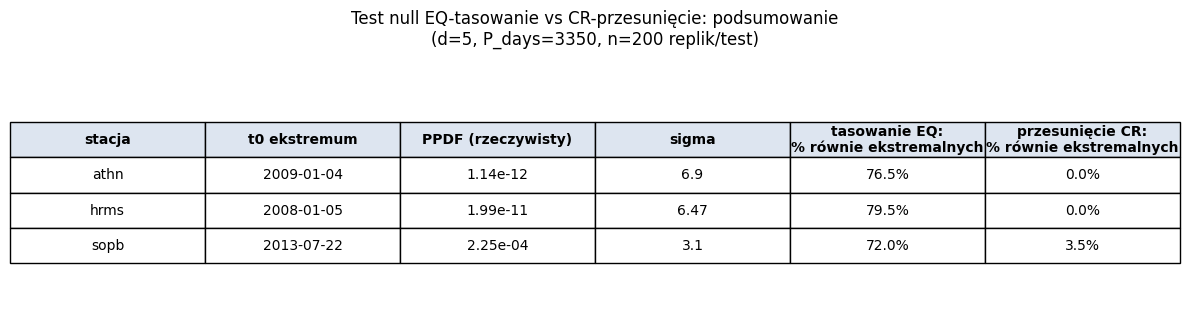

In [7]:
# Ladna tabela podsumowujaca (renderowana jako obrazek) - do wklejenia w
# dzienniku praktyk obok wykresu z poprzedniej komorki.
table_data = shuffle_df_saved.copy()
table_data["real_sigma"] = table_data["real_sigma"].round(2)
table_data["real_PPDF"] = table_data["real_PPDF"].map(lambda x: f"{x:.2e}")
table_data["frac_eq_shuffle_as_extreme"] = (table_data["frac_eq_shuffle_as_extreme"] * 100).round(1).astype(str) + "%"
table_data["frac_cr_shift_as_extreme"] = (table_data["frac_cr_shift_as_extreme"] * 100).round(1).astype(str) + "%"
table_data = table_data.rename(columns={
    "station": "stacja", "t0": "t0 ekstremum", "real_PPDF": "PPDF (rzeczywisty)",
    "real_sigma": "sigma", "frac_eq_shuffle_as_extreme": "tasowanie EQ:\n% równie ekstremalnych",
    "frac_cr_shift_as_extreme": "przesunięcie CR:\n% równie ekstremalnych",
})

fig, ax = plt.subplots(figsize=(12, 1.6 + 0.55 * len(table_data)))
ax.axis("off")
tbl = ax.table(cellText=table_data.values, colLabels=table_data.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#dde5f0")
        cell.set_text_props(weight="bold")
fig.suptitle("Test null EQ-tasowanie vs CR-przesunięcie: podsumowanie\n(d=5, P_days=3350, n=200 replik/test)", y=0.98)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/eq_cr_shuffle_test_table.png", dpi=150, bbox_inches="tight")
plt.show()


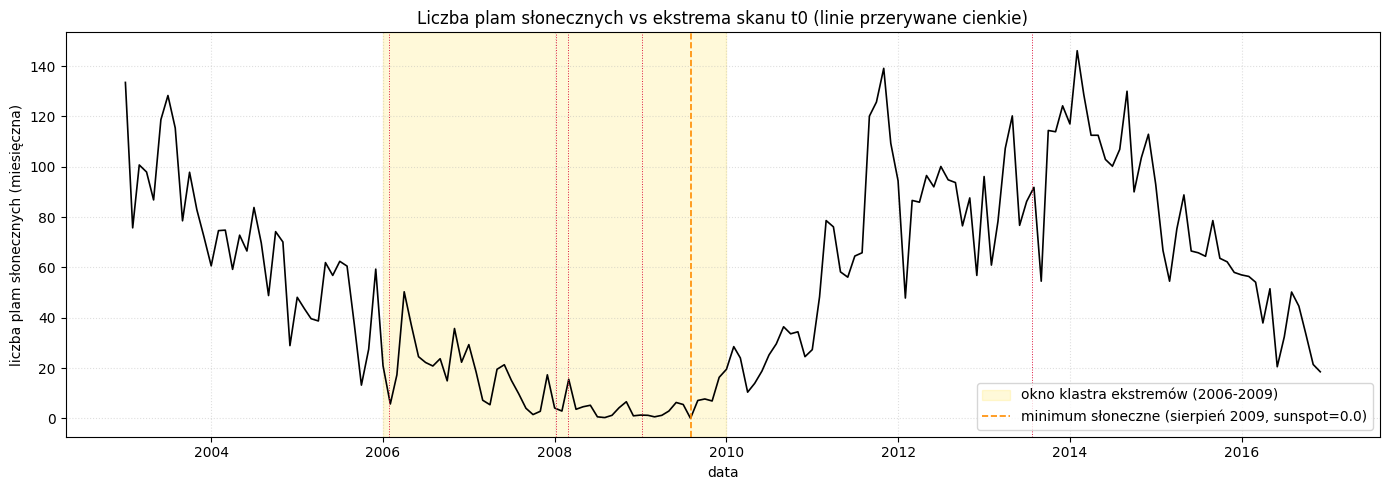

In [8]:
# KROK 6: domkniecie fizycznej narracji - nakladka liczby plam slonecznych
# (SN_m_tot_V2.0.csv, ta sama seria co w 20260703-20260708 przy wyznaczaniu
# cyklu slonecznego LOWESS) na te sama os t0, z ekstremami skanu. Sprawdza
# WPROST (nie na podstawie ogolnej wiedzy, tylko z WLASNYCH danych repo),
# czy klaster 2006-2009 pokrywa sie z realnym minimum slonecznym.
sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
sn_window = sn[(sn["date"] >= "2003-01-01") & (sn["date"] <= "2016-12-31")]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sn_window["date"], sn_window["sunspot"], color="black", lw=1.2)
ax.axvspan(pd.Timestamp("2006-01-01"), pd.Timestamp("2009-12-31"), color="gold", alpha=0.15,
           label="okno klastra ekstremów (2006-2009)")
for s, t0 in extrema_d5.items():
    ax.axvline(t0, color="crimson", lw=0.7, ls=":")
ax.axvline(pd.Timestamp("2009-08-01"), color="darkorange", lw=1.2, ls="--",
           label="minimum słoneczne (sierpień 2009, sunspot=0.0)")
ax.set_xlabel("data")
ax.set_ylabel("liczba plam słonecznych (miesięczna)")
ax.set_title("Liczba plam słonecznych vs ekstrema skanu t0 (linie przerywane cienkie)")
ax.legend()
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
plt.show()
